<a href="https://colab.research.google.com/github/mailtobiswajit02-rgb/Python-Project/blob/main/Copy_of_flight_booking_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

In [ ]:
df = pd.read_csv('/content/Flight_Booking.csv')

In [ ]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop('Unnamed: 0', axis = 1, inplace = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


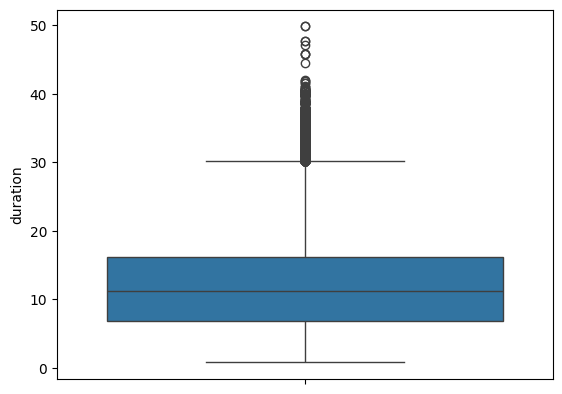

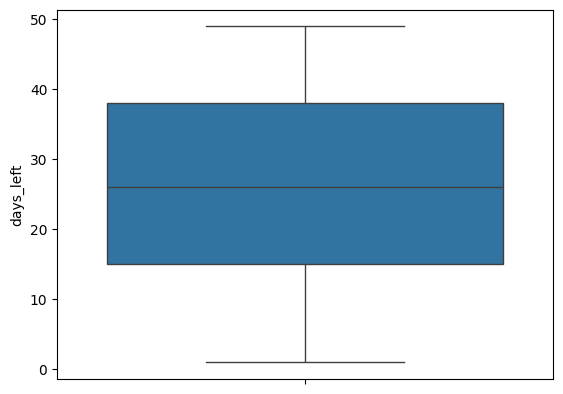

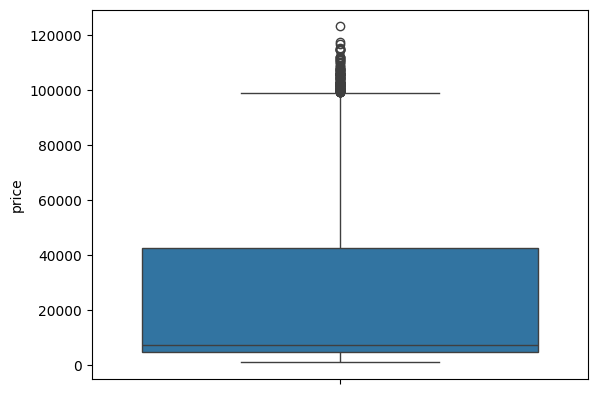

In [ ]:
for i in df.columns:
  if df[i].dtype != 'object':
    sns.boxplot(df[i])
    plt.show()

In [ ]:
df.drop('flight', axis = 1, inplace = True)

In [ ]:
df['stops'].unique()

array(['zero', 'one', 'two_or_more'], dtype=object)

In [ ]:
df['stops'] = df['stops'].replace({
    'zero' : 0,
    'one' : 1,
    'two_or_more' : 2
})

/tmp/ipykernel_7952/4074671616.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['stops'] = df['stops'].replace({


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   source_city       300153 non-null  object 
 2   departure_time    300153 non-null  object 
 3   stops             300153 non-null  int64  
 4   arrival_time      300153 non-null  object 
 5   destination_city  300153 non-null  object 
 6   class             300153 non-null  object 
 7   duration          300153 non-null  float64
 8   days_left         300153 non-null  int64  
 9   price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 22.9+ MB


In [ ]:
categorical_col = ['airline','source_city','departure_time','arrival_time','destination_city','class']
df = pd.get_dummies(df, columns = categorical_col, drop_first = True)

In [ ]:
df

,stops,duration,days_left,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,0,2.17,1,5953,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,True
1,0,2.33,1,5953,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,True
2,0,2.17,1,5956,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
3,0,2.25,1,5955,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,True
4,0,2.33,1,5955,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,10.08,49,69265,False,False,False,False,True,True,...,True,False,False,False,False,False,True,False,False,False
300149,1,10.42,49,77105,False,False,False,False,True,True,...,False,False,False,True,False,False,True,False,False,False
300150,1,13.83,49,79099,False,False,False,False,True,True,...,False,False,False,True,False,False,True,False,False,False
300151,1,10.00,49,81585,False,False,False,False,True,True,...,True,False,False,False,False,False,True,False,False,False


In [ ]:
# col_list = []              # Use a for loop for the same
# for col in df.columns:
#     if df[col].dtype == "float64" and col != "Target":
#         col_list.append(col)
# threshold = 5
# while True:
#     X = df[col_list]
#     vif = []
#     for i in range(len(X.columns)):
#         vif.append(variance_inflation_factor(X.values, i))
#     max_vif = max(vif)
#     if max_vif <= threshold:
#         break
#     remove_col = X.columns[vif.index(max_vif)]
#     print(f"{remove_col} (VIF = {max_vif:.2f})")
#     col_list.remove(remove_col)
# print(col_list)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 30 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   stops                         300153 non-null  int64  
 1   duration                      300153 non-null  float64
 2   days_left                     300153 non-null  int64  
 3   price                         300153 non-null  int64  
 4   airline_Air_India             300153 non-null  bool   
 5   airline_GO_FIRST              300153 non-null  bool   
 6   airline_Indigo                300153 non-null  bool   
 7   airline_SpiceJet              300153 non-null  bool   
 8   airline_Vistara               300153 non-null  bool   
 9   source_city_Chennai           300153 non-null  bool   
 10  source_city_Delhi             300153 non-null  bool   
 11  source_city_Hyderabad         300153 non-null  bool   
 12  source_city_Kolkata           300153 non-nul

In [ ]:
col_list = []
for i in df.columns:
  if ((df[i].dtype != 'object') & (i != 'price')):
    col_list.append(i)

x = df[col_list]
x = x.astype(int)
vif_data = pd.DataFrame()
vif_data['columns name'] = x.columns
vif_data['vif score'] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
print(vif_data)

                    columns name  vif score
0                          stops   8.232025
1                       duration   6.449762
2                      days_left   4.383979
3              airline_Air_India   5.061768
4               airline_GO_FIRST   1.992489
5                 airline_Indigo   2.802756
6               airline_SpiceJet   1.449455
7                airline_Vistara   7.101335
8            source_city_Chennai   1.730531
9              source_city_Delhi   2.091861
10         source_city_Hyderabad   1.773747
11           source_city_Kolkata   1.871020
12            source_city_Mumbai   2.146773
13  departure_time_Early_Morning   2.262915
14        departure_time_Evening   2.331559
15     departure_time_Late_Night   1.046694
16        departure_time_Morning   2.367060
17          departure_time_Night   2.023807
18    arrival_time_Early_Morning   1.420772
19          arrival_time_Evening   2.858226
20       arrival_time_Late_Night   1.369850
21          arrival_time_Morning

In [ ]:
df.drop('stops', axis = 1, inplace = True)

In [ ]:
col_list = []
for i in df.columns:
  if ((df[i].dtype != 'object') & (i != 'price')):
    col_list.append(i)

x = df[col_list]
x = x.astype(int)
vif_data = pd.DataFrame()
vif_data['columns name'] = x.columns
vif_data['vif score'] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
print(vif_data)

                    columns name  vif score
0                       duration   4.927731
1                      days_left   4.350982
2              airline_Air_India   5.045846
3               airline_GO_FIRST   1.979037
4                 airline_Indigo   2.788941
5               airline_SpiceJet   1.445887
6                airline_Vistara   7.008753
7            source_city_Chennai   1.723238
8              source_city_Delhi   2.082977
9          source_city_Hyderabad   1.765531
10           source_city_Kolkata   1.855228
11            source_city_Mumbai   2.136966
12  departure_time_Early_Morning   2.252169
13        departure_time_Evening   2.327879
14     departure_time_Late_Night   1.046678
15        departure_time_Morning   2.351290
16          departure_time_Night   2.017446
17    arrival_time_Early_Morning   1.416159
18          arrival_time_Evening   2.811413
19       arrival_time_Late_Night   1.342634
20          arrival_time_Morning   2.535594
21            arrival_time_Night

In [ ]:
x = df.drop('price', axis = 1)
y = df['price']

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [ ]:
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import *

In [ ]:
r2 = r2_score(y_test, y_pred)
r2

0.9031705776172319

In [ ]:
def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R-squared Score (R2): {r2:.4f}")

evaluate_model(y_test, y_pred)

Mean Absolute Error (MAE): 4450.31
Mean Squared Error (MSE): 49913850.80
Root Mean Squared Error (RMSE): 7064.97
R-squared Score (R2): 0.9032


In [ ]:
from sklearn.tree import DecisionTreeRegressor
model1 = DecisionTreeRegressor(random_state = 42)

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_5575/2239405919.py", line 1, in <cell line: 0>
    from sklearn.tree import DecisionTreeClassifier
  File "/usr/local/lib/python3.12/dist-packages/sklearn/tree/__init__.py", line 6, in <module>
    from ._classes import (
  File "/usr/local/lib/python3.12/dist-packages/sklearn/tree/_classes.py", line 40, in <module>
    from . import _criterion, _splitter, _tree
  File "_criterion.pyx", line 1, in init sklearn.tree._criterion
  File "_splitter.pyx", line 1, in init sklearn.tree._splitter
  File "_tree.pyx", line 1, in init sklearn.tree._tree
  File "/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/__init__.py", line 6, in <module>
    from ._ball_tree import BallTree
  File "sklearn/neighbors/_ball_tree.pyx", line 3, in init sklearn.neighbors._ball_tree
  File "/

TypeError: object of type 'NoneType' has no len()

In [ ]:
model1.fit(x_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
dt_pred = model1.predict(x_test)

In [ ]:
evaluate_model(y_test, dt_pred)

Mean Absolute Error (MAE): 1209.69
Mean Squared Error (MSE): 12778968.61
Root Mean Squared Error (RMSE): 3574.77
R-squared Score (R2): 0.9752


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)

print("Random Forest Model Performance:")
evaluate_model(y_test, rf_pred)

Random Forest Model Performance:
Mean Absolute Error (MAE): 1120.55
Mean Squared Error (MSE): 8077209.84
Root Mean Squared Error (RMSE): 2842.04
R-squared Score (R2): 0.9843
